/Users/bindhu/Desktop/DL_AI_Intership/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


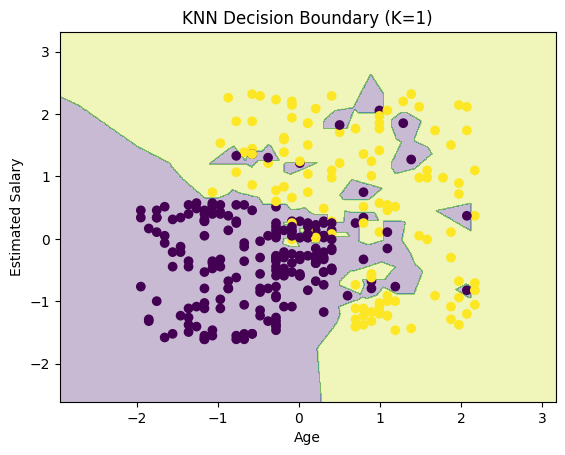

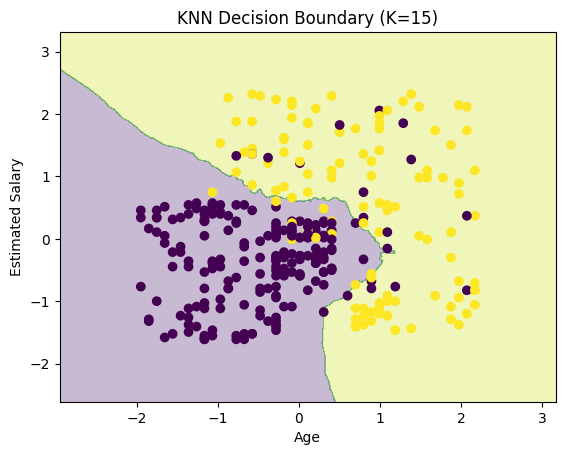

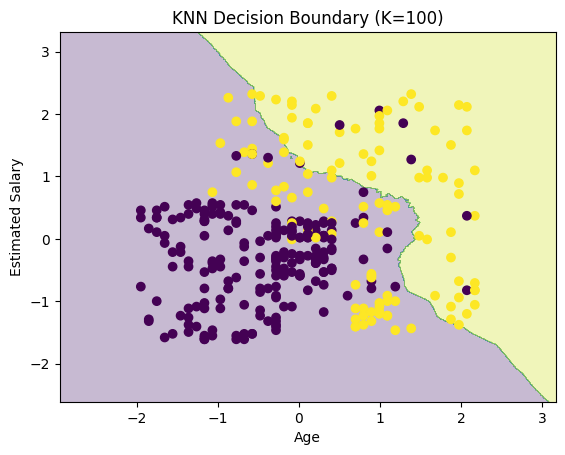

In [1]:
import pandas as pd
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Download dataset
path = kagglehub.dataset_download("rakeshrau/social-network-ads")

# Load dataset
df = pd.read_csv(path + "/Social_Network_Ads.csv")

# Features and target
X = df[["Age", "EstimatedSalary"]].values
y = df["Purchased"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

# Function to plot decision boundary
def plot_knn(K):
    model = KNeighborsClassifier(n_neighbors=K)
    model.fit(X_train, y_train)

    # Mesh grid
    x1, x2 = np.meshgrid(
        np.arange(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 0.01),
        np.arange(X_train[:, 1].min()-1, X_train[:, 1].max()+1, 0.01)
    )

    grid_points = np.c_[x1.ravel(), x2.ravel()]
    Z = model.predict(grid_points).reshape(x1.shape)

    # Plot
    plt.figure()
    plt.contourf(x1, x2, Z, alpha=0.3)
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
    plt.title(f"KNN Decision Boundary (K={K})")
    plt.xlabel("Age")
    plt.ylabel("Estimated Salary")
    plt.show()

# Plot for different K values
plot_knn(1)
plot_knn(15)
plot_knn(100)